# Laya Local + CarRacing v3 — warmed local System-1 driving

[Open in Colab](https://colab.research.google.com/github/vtavakkoli/simple-jev/blob/main/notebooks/Laya_CarRacing_Local_Colab.ipynb)

This version ports the important control-system pieces from the earlier Jev CarRacing notebook while replacing the remote Jev API with local convaiinnovations/laya inference.

Implemented here:
- 1.0 s / 50-frame stationary camera/environment warm-up before any decision.
- Multiple synchronized model warm-up calls, with warm-up wall time separated from racing latency.
- Pixel road geometry with explicit bearing, heading, offsets, widths, and visibility.
- Simulator hull speed telemetry.
- Separate steering and pedal choices in one Laya prediction.
- Current-control state plus recent reward/tile/visibility/bearing/heading/speed outcomes.
- Synthetic left/right/straight/fast/missing-road preflight.
- Per-frame steering/longitudinal slew limits and action-space validation.
- Tile-progress stall watchdog.
- 3,000-frame race, MP4/GIF, JSON/CSV logs, coverage and latency diagnostics.
- No TypeSafe/Jev API key and no external LLM API.

STRICT_PREFLIGHT is false by default so the generic zero-shot Laya checkpoint can still be evaluated when one synthetic case fails. Set it to true if you want preflight to gate the race.

Laya is not a vision model. The RGB frame is converted into a compact structured state. In direct mode there is no hidden lane-follower replacing Laya decisions. Local inference errors stop the experiment instead of silently switching to an expert controller.


In [1]:
#@title 1. Install dependencies
!apt-get -qq update
!apt-get -qq install -y swig > /dev/null
!pip -q install "gymnasium[box2d]==1.3.0" laya imageio imageio-ffmpeg pillow matplotlib pandas


W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 121.5 MB/s eta 0:00:00


In [2]:
#@title 2. Imports, configuration, and local Laya preload
import os
os.environ["USE_TF"] = "0"

import time, json
from collections import Counter, deque
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt

from PIL import Image as PILImage
from IPython.display import Video, Image, display
from laya import Router

MODEL_ID = "convaiinnovations/laya"
MODEL_KEY = "english"
ENV_ID = "CarRacing-v3"
SEED = 0

MAX_STEPS = 3000
SIM_FPS = 50.0
CAMERA_WARMUP_SECONDS = 1.0
CAMERA_WARMUP = int(round(SIM_FPS * CAMERA_WARMUP_SECONDS))
MODEL_WARMUP_CALLS = 5
CONTROL_HORIZON = 4
HISTORY_LEN = 4
STALL_FRAMES = 160
MIN_CONFIDENCE = 0.40
STRICT_PREFLIGHT = False

MAX_STEER_DELTA_PER_FRAME = 0.35
MAX_LONGITUDINAL_DELTA_PER_FRAME = 0.30

VIDEO_EVERY = 2
GIF_EVERY = 5
SCAN_ROWS = [68, 62, 56, 50, 44, 38]

OUTPUT_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
VIDEO_PATH = str(OUTPUT_DIR / "laya_car_racing_local_v2.mp4")
GIF_PATH = str(OUTPUT_DIR / "laya_car_racing_local_v2.gif")
LOG_PATH = str(OUTPUT_DIR / "laya_car_racing_local_v2.json")
CSV_PATH = str(OUTPUT_DIR / "laya_car_racing_local_v2_decisions.csv")
PREFLIGHT_PATH = str(OUTPUT_DIR / "laya_car_racing_local_v2_preflight.json")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True

print("device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Official Router path: keep one checkpoint hot and explicitly preload English.
router = Router(device=DEVICE, max_loaded=1)
router.preload([MODEL_KEY])

print("✓ local Laya preloaded:", MODEL_ID)
print("✓ no API key is used")
print("camera warm-up:", CAMERA_WARMUP, "frames =", CAMERA_WARMUP_SECONDS, "simulated seconds")
print("model warm-up:", MODEL_WARMUP_CALLS, "predictions")
print("control horizon:", CONTROL_HORIZON, "simulation frames")
print("history kept in decision state:", HISTORY_LEN, "decision outcomes")


device: cuda
GPU: Tesla T4


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/laya/router.py:187: RuntimeWarning: laya: this checkpoint ships temperatures outside [0.5, 5] which would distort confidence; clamping choice:11+=0.1006. Treat confidence from the affected buckets as uncalibrated.
  agent = Agent(repo, device=self.device, token=self.token, subfolder=sub)


✓ local Laya preloaded: convaiinnovations/laya
✓ no API key is used
camera warm-up: 50 frames = 1.0 simulated seconds
model warm-up: 5 predictions
control horizon: 4 simulation frames
history kept in decision state: 4 decision outcomes


In [3]:
#@title 3. Road perception, speed telemetry, and stationary camera warm-up
def road_mask_from_rgb(frame):
    img = np.asarray(frame, dtype=np.float32)
    mask = (
        (np.ptp(img, axis=2) < 22)
        & (img.mean(axis=2) > 58)
        & (img.mean(axis=2) < 175)
    )
    mask[82:] = False
    return mask

def scan_road(mask):
    previous_center = 48.0
    centers, widths, valid = [], [], []

    for y in SCAN_ROWS:
        xs = np.flatnonzero(mask[y])
        groups = np.split(xs, np.where(np.diff(xs) > 8)[0] + 1) if len(xs) else []
        groups = [g for g in groups if len(g) >= 3]

        if not groups:
            centers.append(None)
            widths.append(0.0)
            valid.append(False)
            continue

        g = min(groups, key=lambda z: abs((z[0] + z[-1]) / 2.0 - previous_center))
        previous_center = float((g[0] + g[-1]) / 2.0)
        centers.append((previous_center - 48.0) / 48.0)
        widths.append(float(g[-1] - g[0] + 1) / 96.0)
        valid.append(True)

    return centers, widths, valid

def read_speed(env):
    try:
        return float(np.linalg.norm(env.unwrapped.car.hull.linearVelocity))
    except Exception:
        return 0.0

def read_angular_velocity(env):
    try:
        return float(env.unwrapped.car.hull.angularVelocity)
    except Exception:
        return 0.0

def extract_visual_state(frame, speed, angular_velocity=0.0):
    centers, widths, valid = scan_road(road_mask_from_rgb(frame))
    rows = [(y, c) for y, c, ok in zip(SCAN_ROWS, centers, valid) if ok]

    target = min(rows, key=lambda row: abs(row[0] - 50)) if rows else None
    bearing = (
        float(np.degrees(np.arctan2(48.0 * target[1], 72.0 - target[0])))
        if target else None
    )
    heading = (
        float(np.degrees(np.arctan2(
            48.0 * (rows[-1][1] - rows[0][1]),
            rows[0][0] - rows[-1][0]
        )))
        if len(rows) >= 2 else None
    )

    speed_band = (
        "stopped" if speed < 3 else
        "slow" if speed < 12 else
        "turn_speed" if speed < 17 else
        "cruise" if speed < 23 else
        "fast" if speed < 32 else
        "very_fast"
    )

    return {
        "visible_road_bearing_degrees": bearing,
        "visible_road_heading_degrees": heading,
        "bearing_semantics": "negative=LEFT, positive=RIGHT, zero=straight; measured from car toward visible road center",
        "heading_semantics": "negative means road bends left as it recedes; positive means road bends right",
        "road_center_offsets_near_to_far": centers,
        "road_width_fraction_near_to_far": widths,
        "scanline_valid": valid,
        "road_visibility": float(np.mean(valid)),
        "near_center_offset": rows[0][1] if rows else None,
        "far_center_offset": rows[-1][1] if rows else None,
        "speed": float(speed),
        "speed_band": speed_band,
        "angular_velocity": float(angular_velocity),
        "speed_source": "Gymnasium simulator hull velocity magnitude; not estimated from pixels",
    }

def perception_overlay(frame):
    out = np.asarray(frame).copy()
    mask = road_mask_from_rgb(frame)
    out[mask] = (0.60 * out[mask] + 0.40 * np.array([255, 255, 0])).astype(np.uint8)

    centers, _, valid = scan_road(mask)
    for y, c, ok in zip(SCAN_ROWS, centers, valid):
        if ok:
            x = int(np.clip(round(48 + 48 * c), 0, 95))
            out[y-1:y+2, max(0,x-1):min(96,x+2)] = [255, 0, 255]
    return out

def reset_race(env, seed):
    obs, info = env.reset(seed=seed)
    warmup_reward = 0.0
    zero_action = np.zeros(3, dtype=np.float32)
    if not env.action_space.contains(zero_action):
        raise RuntimeError(f"Warm-up action is outside CarRacing action space: {zero_action}")

    for i in range(CAMERA_WARMUP):
        obs, reward, terminated, truncated, info = env.step(zero_action)
        warmup_reward += float(reward)

        if terminated or truncated:
            raise RuntimeError(
                f"Environment ended during stationary camera warm-up at frame {i+1}"
            )

    return obs, info, warmup_reward


In [4]:
#@title 4. Direct Laya steering/pedal decision schema
DIRECT_STEERING = {
    "hard_left": -0.80,
    "left": -0.45,
    "gentle_left": -0.20,
    "slight_left": -0.07,
    "straight": 0.00,
    "slight_right": 0.07,
    "gentle_right": 0.20,
    "right": 0.45,
    "hard_right": 0.80,
}

DIRECT_PEDALS = {
    "accelerate": 0.20,
    "light_throttle": 0.06,
    "coast": 0.00,
    "brake": -0.20,
}

# Keep criteria deliberately compact: the English Laya checkpoint has a short context.
STEERING_CRITERIA = {
    "hard_left": "bearing < -25 deg",
    "left": "-25 <= bearing < -12 deg",
    "gentle_left": "-12 <= bearing < -5 deg",
    "slight_left": "-5 <= bearing < -1.5 deg",
    "straight": "-1.5 <= bearing <= +1.5 deg",
    "slight_right": "+1.5 < bearing <= +5 deg",
    "gentle_right": "+5 < bearing <= +12 deg",
    "right": "+12 < bearing <= +25 deg",
    "hard_right": "bearing > +25 deg",
}

PEDAL_CRITERIA = {
    "accelerate": "visible; speed < 12",
    "light_throttle": "visible; speed 12-18; not a sharp turn",
    "coast": "speed 18-22 straight, or 12-16 in a turn",
    "brake": "speed > 22, or speed > 16 in a bend, or road missing",
}

QUESTIONS = {
    "steering": {
        "type": "choice",
        "instructions": "Choose absolute steering from CURRENT bearing. Negative=left, positive=right. Missing bearing is unknown.",
        "criteria": STEERING_CRITERIA,
    },
    "pedals": {
        "type": "choice",
        "instructions": "Choose independently from CURRENT speed, bearing and visibility. Missing road => brake.",
        "criteria": PEDAL_CRITERIA,
    },
}

def to_gym_action(control):
    steer, longitudinal = np.clip(np.asarray(control, dtype=np.float32), -1, 1)
    return np.array([
        float(steer),
        max(float(longitudinal), 0.0),
        max(-float(longitudinal), 0.0),
    ], dtype=np.float32)

def _field(x, key, default=None):
    return x.get(key, default) if isinstance(x, dict) else getattr(x, key, default)

def _validate_answer(answer, choices, name):
    choice = _field(answer, "choice")
    confidence = float(_field(answer, "confidence", 0.0))
    probabilities = _field(answer, "probabilities", {}) or {}

    if choice not in choices:
        raise ValueError(f"Invalid {name} choice from Laya: {choice!r}")
    if not np.isfinite(confidence) or not 0.0 <= confidence <= 1.0:
        raise ValueError(f"Invalid {name} confidence from Laya: {confidence!r}")

    clean_probs = {}
    for key, value in dict(probabilities).items():
        value = float(value)
        if key not in choices or not np.isfinite(value) or not 0.0 <= value <= 1.0:
            raise ValueError(f"Invalid {name} probability: {key}={value}")
        clean_probs[str(key)] = value

    return {
        "choice": choice,
        "confidence": confidence,
        "probabilities": clean_probs,
    }


In [5]:
#@title 5. Local Laya racing policy with compact action-outcome memory
class LayaCarRacingPolicy:
    def __init__(self, router):
        self.router = router
        self.history = deque(maxlen=HISTORY_LEN)
        self.current_control = np.array([0.0, 0.0], dtype=np.float32)

    @staticmethod
    def compact_vision(vision):
        def r(v, n=2):
            return None if v is None else round(float(v), n)

        return {
            "bearing": r(vision.get("visible_road_bearing_degrees"), 1),
            "heading": r(vision.get("visible_road_heading_degrees"), 1),
            "visibility": r(vision.get("road_visibility"), 2),
            "near": r(vision.get("near_center_offset"), 2),
            "far": r(vision.get("far_center_offset"), 2),
            "speed": r(vision.get("speed"), 1),
            "speed_band": vision.get("speed_band"),
            "omega": r(vision.get("angular_velocity"), 2),
        }

    def state(self, vision, episode_return, step):
        history = []
        for h in self.history:
            history.append({
                "s": h["steering"],
                "p": h["pedals"],
                "r": round(float(h["reward_sum"]), 2),
                "tiles": int(h["tiles_gained"]),
                "vis_after": round(float(h["road_visibility_after"]), 2),
                "b_after": None if h["bearing_after"] is None else round(float(h["bearing_after"]), 1),
                "h_after": None if h["heading_after"] is None else round(float(h["heading_after"]), 1),
                "v_after": round(float(h["speed_after"]), 1),
                "done": bool(h["terminated"]),
            })

        return {
            "task": "CarRacing-v3: follow road, visit tiles, avoid leaving track",
            "sign": "bearing<0 LEFT; bearing>0 RIGHT",
            "step": int(step),
            "return": round(float(episode_return), 1),
            "now": self.compact_vision(vision),
            "control": [
                round(float(self.current_control[0]), 2),
                round(float(self.current_control[1]), 2),
            ],
            "recent": history,
        }

    def call(self, state):
        if DEVICE == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        response = self.router.predict(
            state,
            QUESTIONS,
            model=MODEL_KEY,
        )

        if DEVICE == "cuda":
            torch.cuda.synchronize()
        latency_ms = (time.perf_counter() - t0) * 1000.0

        answers = _field(response, "answers", {})
        if "steering" not in answers or "pedals" not in answers:
            raise ValueError(f"Laya response missing steering/pedals answers: {answers!r}")

        steering = _validate_answer(answers["steering"], DIRECT_STEERING, "steering")
        pedals = _validate_answer(answers["pedals"], DIRECT_PEDALS, "pedals")

        target = np.array([
            DIRECT_STEERING[steering["choice"]],
            DIRECT_PEDALS[pedals["choice"]],
        ], dtype=np.float32)

        return {
            "choice": steering["choice"] + "/" + pedals["choice"],
            "confidence": min(steering["confidence"], pedals["confidence"]),
            "steering_answer": steering,
            "pedals_answer": pedals,
            "target_control": target,
            "latency_ms": latency_ms,
        }

    def decide(self, vision, episode_return, step):
        return self.call(self.state(vision, episode_return, step))

    def record(self, decision, control, rewards, terminated, vision_after, tiles_gained):
        self.history.append({
            "steering": decision["steering_answer"]["choice"],
            "pedals": decision["pedals_answer"]["choice"],
            "control": np.asarray(control, dtype=np.float32).copy(),
            "reward_sum": float(np.sum(rewards)),
            "terminated": bool(terminated),
            "road_visibility_after": float(vision_after["road_visibility"]),
            "bearing_after": vision_after.get("visible_road_bearing_degrees"),
            "heading_after": vision_after.get("visible_road_heading_degrees"),
            "speed_after": float(vision_after["speed"]),
            "tiles_gained": int(tiles_gained),
        })

print("✓ Laya racing policy ready")


✓ Laya racing policy ready


In [6]:
#@title 6. Warm up Laya model and run direct-control preflight
def synthetic_vision(bearing, speed, heading=None):
    if bearing is None:
        offsets = [None] * len(SCAN_ROWS)
        valid = [False] * len(SCAN_ROWS)
        widths = [0.0] * len(SCAN_ROWS)
        visibility = 0.0
    else:
        offsets = [
            float(np.clip(np.tan(np.radians(bearing)) * (72-y) / 48.0, -1, 1))
            for y in SCAN_ROWS
        ]
        valid = [True] * len(SCAN_ROWS)
        widths = [0.25] * len(SCAN_ROWS)
        visibility = 1.0

    return {
        "visible_road_bearing_degrees": bearing,
        "visible_road_heading_degrees": bearing if heading is None else heading,
        "bearing_semantics": "negative=LEFT, positive=RIGHT, zero=straight",
        "heading_semantics": "negative=left bend, positive=right bend",
        "road_center_offsets_near_to_far": offsets,
        "road_width_fraction_near_to_far": widths,
        "scanline_valid": valid,
        "road_visibility": visibility,
        "near_center_offset": offsets[0],
        "far_center_offset": offsets[-1],
        "speed": float(speed),
        "speed_band": "synthetic",
        "angular_velocity": 0.0,
        "speed_source": "synthetic preflight",
    }

warm_policy = LayaCarRacingPolicy(router)
warm_state = warm_policy.state(synthetic_vision(0.0, 4.0), 0.0, CAMERA_WARMUP)

print("=== MODEL WARM-UP ===")
warm_latencies = []
model_warmup_t0 = time.perf_counter()
for i in range(MODEL_WARMUP_CALLS):
    d = warm_policy.call(warm_state)
    warm_latencies.append(d["latency_ms"])
    print(
        f"warm-up {i+1}/{MODEL_WARMUP_CALLS}: "
        f"{d['choice']} | {d['confidence']:.3f} | {d['latency_ms']:.1f} ms"
    )

model_warmup_wall_ms = (time.perf_counter() - model_warmup_t0) * 1000.0
if len(warm_latencies) > 1:
    print("first-call latency:", round(warm_latencies[0], 1), "ms")
    print("post-warm-up mean:", round(float(np.mean(warm_latencies[1:])), 1), "ms")
print("model warm-up total wall time:", round(model_warmup_wall_ms, 1), "ms")

# Validate every discrete steering/pedal mapping against the actual Gymnasium action space.
_test_env = gym.make(ENV_ID, continuous=True, domain_randomize=False)
try:
    for steer_name, steer in DIRECT_STEERING.items():
        for pedal_name, longitudinal in DIRECT_PEDALS.items():
            action = to_gym_action(np.array([steer, longitudinal], dtype=np.float32))
            if not _test_env.action_space.contains(action):
                raise RuntimeError(
                    f"Invalid action mapping {steer_name}/{pedal_name}: {action}"
                )
finally:
    _test_env.close()
print("✓ all steering/pedal mappings are inside the CarRacing action space")

def run_direct_preflight():
    policy = LayaCarRacingPolicy(router)
    cases = [
        ("centered_slow", 0.0, 4.0, {"straight"}, {"accelerate"}),
        ("left_turn", -18.0, 10.0, {"left", "hard_left", "gentle_left"}, None),
        ("right_turn", 18.0, 10.0, {"right", "hard_right", "gentle_right"}, None),
        ("centered_fast", 0.0, 40.0, {"straight"}, {"brake"}),
        ("missing_road", None, 25.0, None, {"brake"}),
    ]

    results = []
    print("\n=== DIRECT-CONTROL PREFLIGHT ===")
    for name, bearing, speed, allowed_steering, allowed_pedals in cases:
        vision = synthetic_vision(bearing, speed)
        d = policy.decide(vision, 0.0, CAMERA_WARMUP)
        steer = d["steering_answer"]["choice"]
        pedal = d["pedals_answer"]["choice"]

        passed = (
            (allowed_steering is None or steer in allowed_steering)
            and (allowed_pedals is None or pedal in allowed_pedals)
        )

        row = {
            "case": name,
            "passed": bool(passed),
            "steering": steer,
            "pedals": pedal,
            "confidence": float(d["confidence"]),
            "latency_ms": float(d["latency_ms"]),
            "steering_answer": d["steering_answer"],
            "pedals_answer": d["pedals_answer"],
        }
        results.append(row)
        print(
            f"{name:14s} {'PASS' if passed else 'FAIL'} | "
            f"{steer:>12s} | {pedal:>14s} | "
            f"conf={d['confidence']:.3f} | {d['latency_ms']:.1f} ms"
        )

    Path(PREFLIGHT_PATH).write_text(
        json.dumps(results, indent=2, allow_nan=False),
        encoding="utf-8",
    )

    passed_all = all(r["passed"] for r in results)
    if not passed_all:
        msg = (
            "Laya failed at least one synthetic direct-control case. "
            "This is evidence about zero-shot transfer, not a notebook failure."
        )
        if STRICT_PREFLIGHT:
            raise RuntimeError(msg + " STRICT_PREFLIGHT=True, so race is blocked.")
        print("WARNING:", msg, "Continuing because STRICT_PREFLIGHT=False.")

    return passed_all, results

PREFLIGHT_PASSED, PREFLIGHT_RESULTS = run_direct_preflight()
print("preflight passed:", PREFLIGHT_PASSED)


=== MODEL WARM-UP ===
warm-up 1/5: left/coast | 0.010 | 917.3 ms
warm-up 2/5: left/coast | 0.010 | 70.4 ms
warm-up 3/5: left/coast | 0.010 | 69.4 ms
warm-up 4/5: left/coast | 0.010 | 69.4 ms
warm-up 5/5: left/coast | 0.010 | 73.7 ms
first-call latency: 917.3 ms
post-warm-up mean: 70.7 ms
model warm-up total wall time: 1202.0 ms
✓ all steering/pedal mappings are inside the CarRacing action space

=== DIRECT-CONTROL PREFLIGHT ===
centered_slow  FAIL |         left |          coast | conf=0.010 | 61.1 ms
left_turn      PASS |         left |          coast | conf=0.025 | 63.4 ms
right_turn     FAIL |         left |          coast | conf=0.011 | 57.4 ms
centered_fast  FAIL |         left |          coast | conf=0.014 | 61.0 ms
missing_road   FAIL |         left |          coast | conf=0.020 | 62.8 ms
preflight passed: False


camera warm-up: 50 frames / 1.0 simulated s
warm-up reward: 1.27
{
  "visible_road_bearing_degrees": -1.3019526725788753,
  "visible_road_heading_degrees": 0.0,
  "bearing_semantics": "negative=LEFT, positive=RIGHT, zero=straight; measured from car toward visible road center",
  "heading_semantics": "negative means road bends left as it recedes; positive means road bends right",
  "road_center_offsets_near_to_far": [
    -0.010416666666666666,
    -0.010416666666666666,
    -0.010416666666666666,
    -0.010416666666666666,
    -0.010416666666666666,
    -0.010416666666666666
  ],
  "road_width_fraction_near_to_far": [
    0.20833333333333334,
    0.20833333333333334,
    0.20833333333333334,
    0.20833333333333334,
    0.20833333333333334,
    0.20833333333333334
  ],
  "scanline_valid": [
    true,
    true,
    true,
    true,
    true,
    true
  ],
  "road_visibility": 1.0,
  "near_center_offset": -0.010416666666666666,
  "far_center_offset": -0.010416666666666666,
  "speed": 5.59

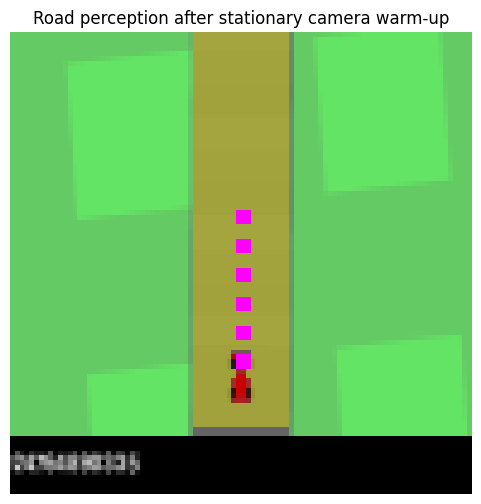

In [7]:
#@title 7. Perception check after the real 1.0 s / 50-frame camera warm-up
with gym.make(
    ENV_ID,
    render_mode="rgb_array",
    continuous=True,
    domain_randomize=False,
    max_episode_steps=MAX_STEPS,
) as env:
    obs, _, warmup_reward = reset_race(env, SEED)
    vision = extract_visual_state(
        obs,
        read_speed(env),
        read_angular_velocity(env),
    )

    print("camera warm-up:", CAMERA_WARMUP, "frames /", CAMERA_WARMUP_SECONDS, "simulated s")
    print("warm-up reward:", round(warmup_reward, 3))
    print(json.dumps(vision, indent=2))

    plt.figure(figsize=(6, 6))
    plt.imshow(perception_overlay(obs))
    plt.title("Road perception after stationary camera warm-up")
    plt.axis("off")
    plt.show()


In [8]:
#@title 8. Run local Laya racing
if STRICT_PREFLIGHT and not PREFLIGHT_PASSED:
    raise RuntimeError("Strict preflight is enabled and preflight did not pass.")

policy = LayaCarRacingPolicy(router)

env = gym.make(
    ENV_ID,
    render_mode="rgb_array",
    continuous=True,
    domain_randomize=False,
    max_episode_steps=MAX_STEPS,
)

obs, _, episode_return = reset_race(env, SEED)
step = CAMERA_WARMUP

reward_history = []
steer_history = []
long_history = []
visibility_history = []
speed_history = []
confidence_history = []
decision_log = []
gif_frames = []

laya_failures = 0
low_confidence_decisions = 0
last_progress_step = step
visited = int(env.unwrapped.tile_visited_count)
stop_reason = "frame_limit"
terminated = truncated = False

writer = imageio.get_writer(
    VIDEO_PATH,
    format="FFMPEG",
    mode="I",
    fps=50.0 / VIDEO_EVERY,
    codec="libx264",
    pixelformat="yuv420p",
    macro_block_size=1,
)

try:
    while step < MAX_STEPS:
        vision_before = extract_visual_state(
            obs,
            read_speed(env),
            read_angular_velocity(env),
        )

        try:
            decision = policy.decide(
                vision_before,
                episode_return,
                step,
            )
        except Exception as error:
            laya_failures += 1
            stop_reason = "laya_error"
            decision_log.append({
                "step": int(step),
                "error": repr(error),
                "stop_reason": stop_reason,
            })
            print("Local Laya error -> stopping direct experiment:", repr(error))
            break

        low_confidence_decisions += int(
            decision["confidence"] < MIN_CONFIDENCE
        )

        rewards = []
        tiles_before = int(env.unwrapped.tile_visited_count)
        control = policy.current_control.copy()
        vision_after = vision_before

        for _ in range(min(CONTROL_HORIZON, MAX_STEPS - step)):
            target = decision["target_control"]

            delta = np.clip(
                target - policy.current_control,
                [-MAX_STEER_DELTA_PER_FRAME, -MAX_LONGITUDINAL_DELTA_PER_FRAME],
                [ MAX_STEER_DELTA_PER_FRAME,  MAX_LONGITUDINAL_DELTA_PER_FRAME],
            )
            control = policy.current_control + delta

            action = to_gym_action(control)
            if not np.isfinite(action).all():
                raise RuntimeError("Non-finite motor action generated")
            if action.shape != (3,):
                raise RuntimeError(f"Invalid CarRacing action shape: {action.shape}")
            if not env.action_space.contains(action):
                raise RuntimeError(f"Motor action outside CarRacing action space: {action}")

            obs, reward, terminated, truncated, _ = env.step(action)

            policy.current_control = control.copy()
            episode_return += float(reward)
            rewards.append(float(reward))
            step += 1

            vision_after = extract_visual_state(
                obs,
                read_speed(env),
                read_angular_velocity(env),
            )

            reward_history.append(float(episode_return))
            steer_history.append(float(control[0]))
            long_history.append(float(control[1]))
            visibility_history.append(float(vision_after["road_visibility"]))
            speed_history.append(float(vision_after["speed"]))

            current_visited = int(env.unwrapped.tile_visited_count)
            if current_visited > visited:
                visited = current_visited
                last_progress_step = step

            if step % VIDEO_EVERY == 0:
                writer.append_data(env.render())

            if step % GIF_EVERY == 0:
                gif_frames.append(
                    np.asarray(
                        PILImage.fromarray(env.render()).resize((480, 384))
                    )
                )

            stalled = (step - last_progress_step) >= STALL_FRAMES
            if terminated or truncated or stalled:
                stop_reason = (
                    "terminated" if terminated else
                    "time_limit" if truncated else
                    "no_new_tiles"
                )
                break

        tiles_after = int(env.unwrapped.tile_visited_count)
        tiles_gained = tiles_after - tiles_before

        policy.record(
            decision,
            control,
            rewards,
            terminated or truncated,
            vision_after,
            tiles_gained,
        )

        entry = {
            "step": int(step),
            "choice": decision["choice"],
            "confidence": float(decision["confidence"]),
            "latency_ms": float(decision["latency_ms"]),
            "steering_answer": decision["steering_answer"],
            "pedals_answer": decision["pedals_answer"],
            "requested_control": [float(x) for x in decision["target_control"]],
            "applied_control": [float(x) for x in control],
            "reward_horizon": float(np.sum(rewards)),
            "return_total": float(episode_return),
            "tiles": int(visited),
            "tiles_gained": int(tiles_gained),
            "vision_before": vision_before,
            "vision_after": vision_after,
        }
        decision_log.append(entry)
        confidence_history.append(float(decision["confidence"]))

        if len(decision_log) <= 12 or len(decision_log) % 20 == 0:
            print(
                f"decision {len(decision_log):04d} | step {step:04d} | "
                f"{decision['choice']:>26s} | conf {decision['confidence']:.3f} | "
                f"{decision['latency_ms']:.1f} ms | return {episode_return:+.1f} | "
                f"steer {control[0]:+.2f} | long {control[1]:+.2f} | "
                f"bearing {vision_after['visible_road_bearing_degrees']} | "
                f"speed {vision_after['speed']:.1f} | "
                f"tiles {visited}/{len(env.unwrapped.track)}"
            )

        if terminated or truncated or stalled:
            break

    coverage = (
        float(visited) / float(len(env.unwrapped.track))
        if len(env.unwrapped.track) else 0.0
    )

finally:
    writer.close()
    env.close()

if gif_frames:
    imageio.mimsave(
        GIF_PATH,
        gif_frames,
        duration=1000.0 * GIF_EVERY / 50.0,
        loop=0,
    )

latencies = [
    d["latency_ms"] for d in decision_log
    if d.get("latency_ms") is not None
]
confidences = [
    d["confidence"] for d in decision_log
    if d.get("confidence") is not None
]

summary = {
    "model": MODEL_ID,
    "device": DEVICE,
    "seed": SEED,
    "camera_warmup_frames": CAMERA_WARMUP,
    "camera_warmup_simulated_seconds": CAMERA_WARMUP_SECONDS,
    "model_warmup_calls": MODEL_WARMUP_CALLS,
    "model_warmup_total_wall_ms": float(model_warmup_wall_ms),
    "steps_total_including_camera_warmup": int(step),
    "controlled_steps": int(max(0, step - CAMERA_WARMUP)),
    "total_reward_including_warmup": float(episode_return),
    "road_coverage": float(coverage),
    "tiles_visited": int(visited),
    "decisions": int(len(decision_log)),
    "preflight_passed": bool(PREFLIGHT_PASSED),
    "stop_reason": stop_reason,
    "laya_failures": int(laya_failures),
    "low_confidence_decisions": int(low_confidence_decisions),
    "mean_laya_latency_ms": float(np.mean(latencies)) if latencies else None,
    "p95_laya_latency_ms": float(np.percentile(latencies, 95)) if latencies else None,
    "mean_laya_confidence": float(np.mean(confidences)) if confidences else None,
    "steering_counts": dict(Counter(
        d["steering_answer"]["choice"]
        for d in decision_log
        if "steering_answer" in d
    )),
    "pedal_counts": dict(Counter(
        d["pedals_answer"]["choice"]
        for d in decision_log
        if "pedals_answer" in d
    )),
}

Path(LOG_PATH).write_text(
    json.dumps(
        {
            "summary": summary,
            "model_warmup_latencies_ms": warm_latencies,
            "preflight": PREFLIGHT_RESULTS,
            "decisions": decision_log,
        },
        indent=2,
        allow_nan=False,
    ),
    encoding="utf-8",
)

flat_rows = []
for d in decision_log:
    if "steering_answer" not in d:
        continue
    flat_rows.append({
        "step": d["step"],
        "steering": d["steering_answer"]["choice"],
        "pedals": d["pedals_answer"]["choice"],
        "confidence": d["confidence"],
        "latency_ms": d["latency_ms"],
        "requested_steer": d["requested_control"][0],
        "requested_longitudinal": d["requested_control"][1],
        "applied_steer": d["applied_control"][0],
        "applied_longitudinal": d["applied_control"][1],
        "reward_horizon": d["reward_horizon"],
        "return_total": d["return_total"],
        "tiles": d["tiles"],
        "tiles_gained": d["tiles_gained"],
        "bearing_before": d["vision_before"]["visible_road_bearing_degrees"],
        "heading_before": d["vision_before"]["visible_road_heading_degrees"],
        "visibility_before": d["vision_before"]["road_visibility"],
        "speed_before": d["vision_before"]["speed"],
    })

pd.DataFrame(flat_rows).to_csv(CSV_PATH, index=False)

print("\n=== RESULT ===")
print(json.dumps(summary, indent=2))


decision 0001 | step 0054 |                 left/coast | conf 0.007 | 80.7 ms | return +0.9 | steer -0.45 | long +0.00 | bearing -1.3019526725788753 | speed 0.0 | tiles 2/319
decision 0002 | step 0058 |                 left/coast | conf 0.004 | 100.4 ms | return +0.5 | steer -0.45 | long +0.00 | bearing -1.3019526725788753 | speed 0.0 | tiles 2/319
decision 0003 | step 0062 |                 left/coast | conf 0.005 | 120.4 ms | return +0.1 | steer -0.45 | long +0.00 | bearing -1.3019526725788753 | speed 0.0 | tiles 2/319
decision 0004 | step 0066 |                 left/coast | conf 0.002 | 135.5 ms | return -0.3 | steer -0.45 | long +0.00 | bearing -1.3019526725788753 | speed 0.0 | tiles 2/319
decision 0005 | step 0070 |                 left/coast | conf 0.001 | 105.7 ms | return -0.7 | steer -0.45 | long +0.00 | bearing -1.3019526725788753 | speed 0.0 | tiles 2/319
decision 0006 | step 0074 |                 left/coast | conf 0.001 | 93.1 ms | return -1.1 | steer -0.45 | long +0.00 | 

MP4:


GIF:


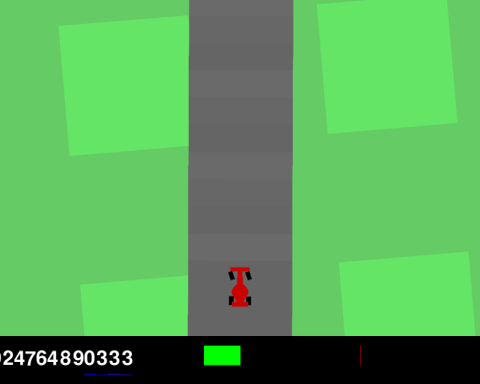

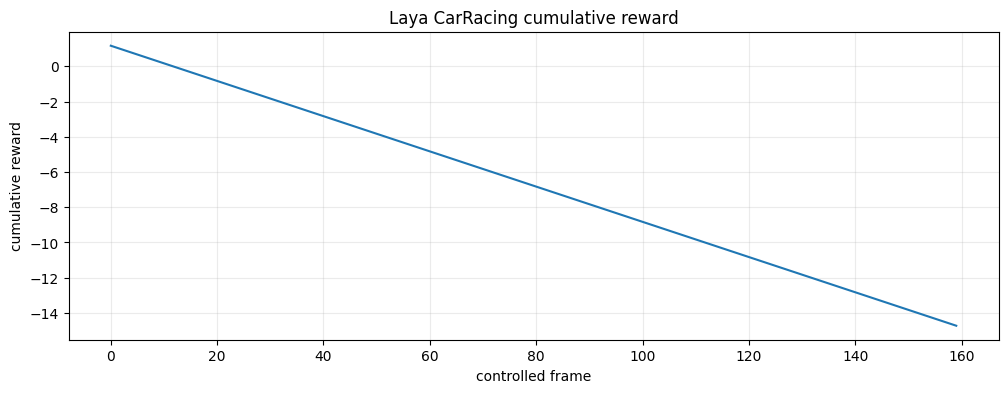

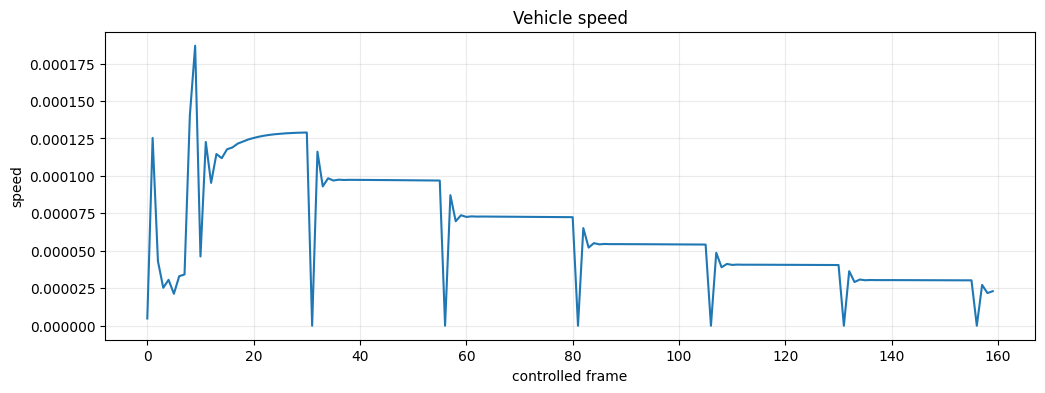

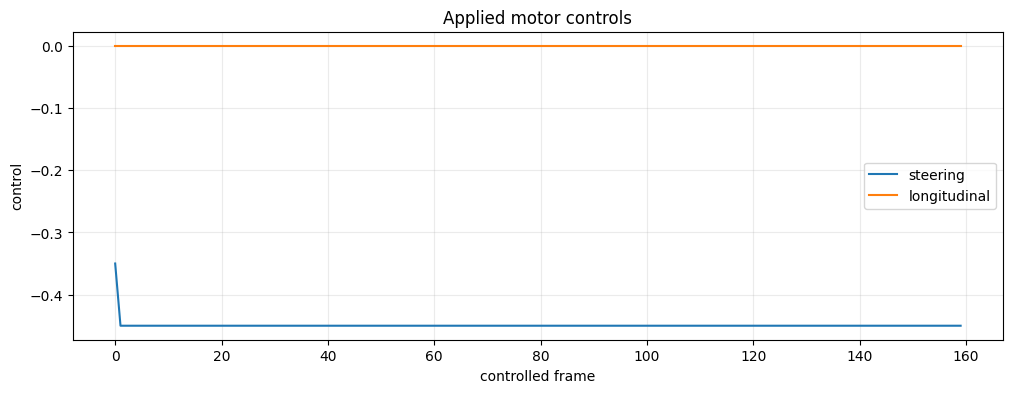

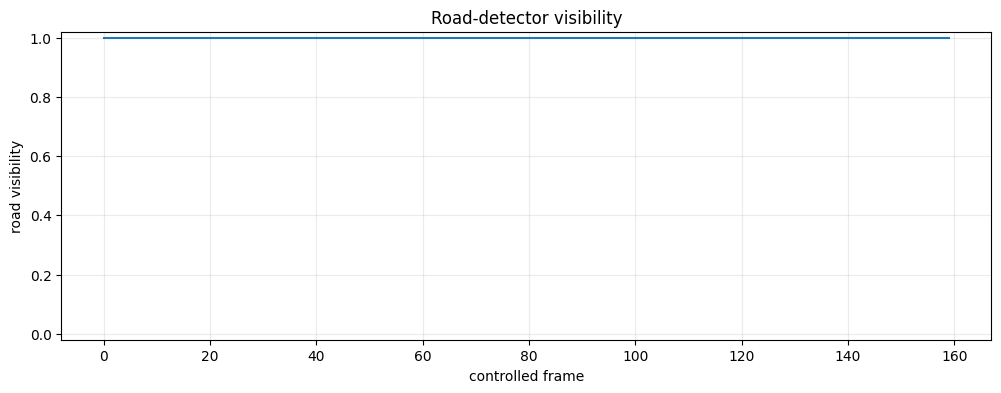

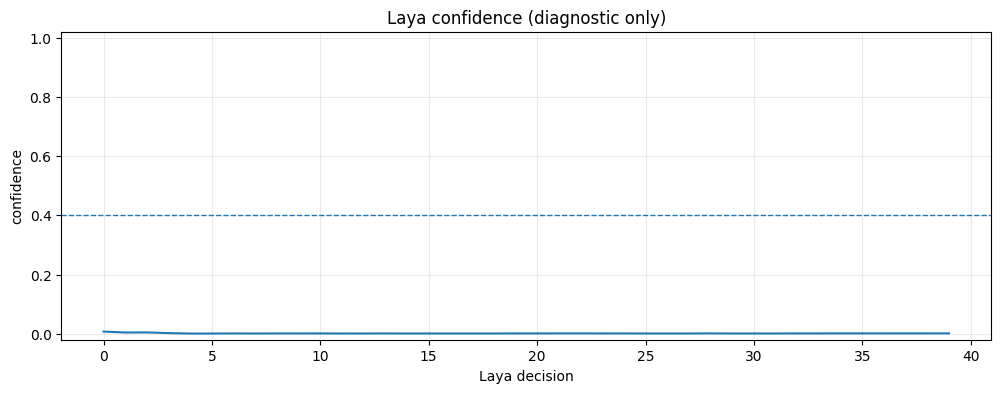

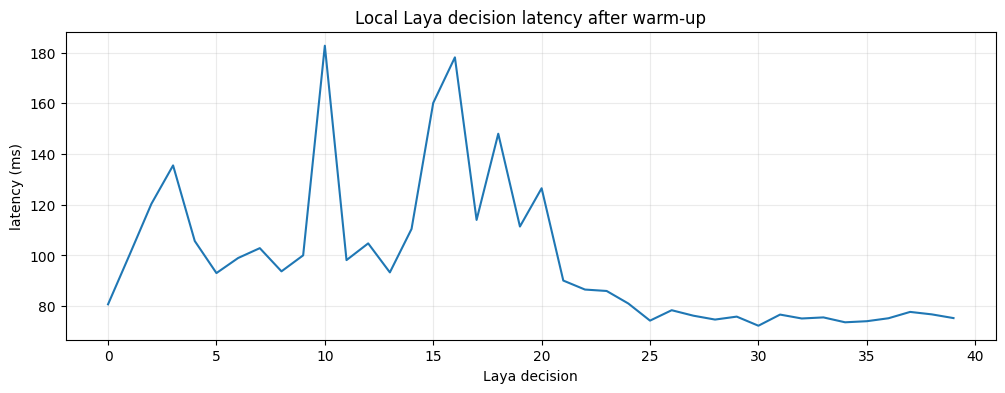

,step,steering,pedals,confidence,latency_ms,requested_steer,requested_longitudinal,applied_steer,applied_longitudinal,reward_horizon,return_total,tiles,tiles_gained,bearing_before,heading_before,visibility_before,speed_before
15,114,left,coast,0.0011,160.135159,-0.45,0.0,-0.45,0.0,-0.4,-5.130408,2,0,-1.301953,0.0,1.0,0.000074
16,118,left,coast,0.0011,178.102848,-0.45,0.0,-0.45,0.0,-0.4,-5.530408,2,0,-1.301953,0.0,1.0,0.000073
17,122,left,coast,0.0011,114.014481,-0.45,0.0,-0.45,0.0,-0.4,-5.930408,2,0,-1.301953,0.0,1.0,0.000073
18,126,left,coast,0.0011,147.998179,-0.45,0.0,-0.45,0.0,-0.4,-6.330408,2,0,-1.301953,0.0,1.0,0.000073
19,130,left,coast,0.0013,111.412444,-0.45,0.0,-0.45,0.0,-0.4,-6.730408,2,0,-1.301953,0.0,1.0,0.000073
20,134,left,coast,0.0013,126.503842,-0.45,0.0,-0.45,0.0,-0.4,-7.130408,2,0,-1.301953,0.0,1.0,0.000072
21,138,left,coast,0.0014,90.110744,-0.45,0.0,-0.45,0.0,-0.4,-7.530408,2,0,-1.301953,0.0,1.0,0.000052
22,142,left,coast,0.0014,86.563447,-0.45,0.0,-0.45,0.0,-0.4,-7.930408,2,0,-1.301953,0.0,1.0,0.000054
23,146,left,coast,0.0013,86.005346,-0.45,0.0,-0.45,0.0,-0.4,-8.330408,2,0,-1.301953,0.0,1.0,0.000054
24,150,left,coast,0.0012,81.062207,-0.45,0.0,-0.45,0.0,-0.4,-8.730408,2,0,-1.301953,0.0,1.0,0.000054


video: /content/laya_car_racing_local_v2.mp4
gif: /content/laya_car_racing_local_v2.gif
preflight: /content/laya_car_racing_local_v2_preflight.json
log: /content/laya_car_racing_local_v2.json
csv: /content/laya_car_racing_local_v2_decisions.csv


In [9]:
#@title 9. Video, GIF, and diagnostics
print("MP4:")
display(Video(VIDEO_PATH, embed=True, html_attributes="controls loop"))

if Path(GIF_PATH).exists():
    print("GIF:")
    display(Image(filename=GIF_PATH))

plt.figure(figsize=(12, 4))
plt.plot(reward_history)
plt.xlabel("controlled frame")
plt.ylabel("cumulative reward")
plt.title("Laya CarRacing cumulative reward")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(speed_history)
plt.xlabel("controlled frame")
plt.ylabel("speed")
plt.title("Vehicle speed")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(steer_history, label="steering")
plt.plot(long_history, label="longitudinal")
plt.xlabel("controlled frame")
plt.ylabel("control")
plt.title("Applied motor controls")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(visibility_history)
plt.xlabel("controlled frame")
plt.ylabel("road visibility")
plt.ylim(-0.02, 1.02)
plt.title("Road-detector visibility")
plt.grid(True, alpha=0.25)
plt.show()

if confidence_history:
    plt.figure(figsize=(12, 4))
    plt.plot(confidence_history)
    plt.axhline(MIN_CONFIDENCE, linestyle="--", linewidth=1)
    plt.xlabel("Laya decision")
    plt.ylabel("confidence")
    plt.ylim(-0.02, 1.02)
    plt.title("Laya confidence (diagnostic only)")
    plt.grid(True, alpha=0.25)
    plt.show()

if latencies:
    plt.figure(figsize=(12, 4))
    plt.plot(latencies)
    plt.xlabel("Laya decision")
    plt.ylabel("latency (ms)")
    plt.title("Local Laya decision latency after warm-up")
    plt.grid(True, alpha=0.25)
    plt.show()

display(pd.DataFrame(flat_rows).tail(25))
print("video:", VIDEO_PATH)
print("gif:", GIF_PATH)
print("preflight:", PREFLIGHT_PATH)
print("log:", LOG_PATH)
print("csv:", CSV_PATH)


## Reading the result

This notebook intentionally separates system correctness from Laya policy quality.

If road perception, warm-up, the control loop, logging and video work but the car drives badly, that is a model/prompt/task-transfer result rather than a hidden controller bug. The useful signals are preflight sensitivity, post-warm-up local latency, road coverage, repeated steering/pedal bias, and whether recent negative outcomes change later decisions.

If zero-shot Laya is weak, the next rigorous experiment is to collect structured state to steering/pedal labels from the validated lane follower or a trained CarRacing policy, specialize/calibrate Laya on those decisions, and compare identical seeds against this zero-shot notebook.
